In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats

from ipywidgets import interact
from noshow.config import CLINIC_CONFIG
from pathlib import Path
from noshow.features.appointment_features import (
    add_appointments_last_days,
    add_appointments_same_day,
    add_days_since_created,
    add_days_since_last_appointment,
    add_minutes_early,
    add_time_features,
)
from noshow.features.no_show_features import prev_no_show_features
from noshow.features.patient_features import add_patient_features
from noshow.preprocessing.load_data import (
    load_appointment_csv,
    process_appointments,
    process_postal_codes,
)
from noshow.features.feature_pipeline import create_features
from noshow.visualisation.features_plots import feature_barplot, feature_scatter
from noshow.preprocessing.geo import haversine_distance

In [2]:
appointments_df = load_appointment_csv("../data/raw/poliafspraken_no_show.csv")
appointments_df = process_appointments(appointments_df, CLINIC_CONFIG)

/home/jovyan/No_Show/src/noshow/preprocessing/load_data.py:52: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  appointments_df = pd.read_csv(


before status onbekend 169395
before gender onbekend 169393
after status onbekend 169393
test!!@
before duplicate address_postalcoe onbekend 169393
before start dates NaT onbekend 169393
before duplicate appointmnet_id 169392
non LAsT ONE unique index:
169347


no_show                             no_show    show
ziekenhuis              start                      
HagaZiekenhuis Den Haag 2019-12-01      NaN     5.0
                        2020-01-01     19.0  1139.0
                        2020-02-01     42.0  1519.0
                        2020-03-01     31.0  1259.0
                        2020-04-01     12.0   772.0
...                                     ...     ...
                        2024-11-01    313.0  2805.0
                        2024-12-01    267.0  2525.0
                        2025-01-01    271.0  2760.0
                        2025-02-01    238.0  2351.0
                        2025-03-01     21.0   298.0

[64 rows x 2 columns]


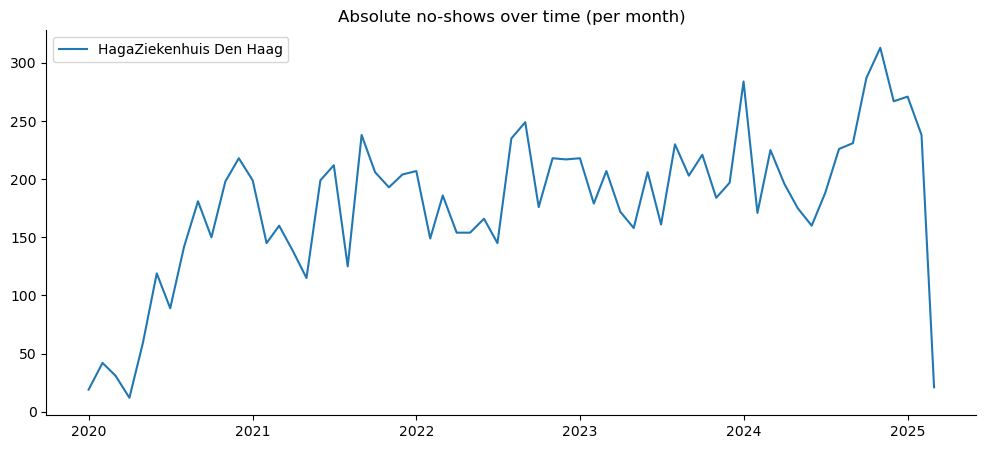

In [3]:
no_show_over_time = appointments_df.copy().reset_index()
no_show_over_time["start"] = (
    no_show_over_time["start"].dt.to_period("M").dt.to_timestamp()
)

no_show_over_time = (
    no_show_over_time.groupby(["ziekenhuis", "start"])["no_show"]
    .value_counts(normalize=False)
    .unstack(level="no_show")
)


print(no_show_over_time)

fig, ax = plt.subplots(figsize=(12, 5))
for idx in no_show_over_time.index.unique(level="ziekenhuis"):
    ax.plot(
        no_show_over_time.loc[idx].index,
        no_show_over_time.loc[idx, "no_show"],
        label=idx,
    )
ax.legend()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.set_title("Absolute no-shows over time (per month)")

plt.show()

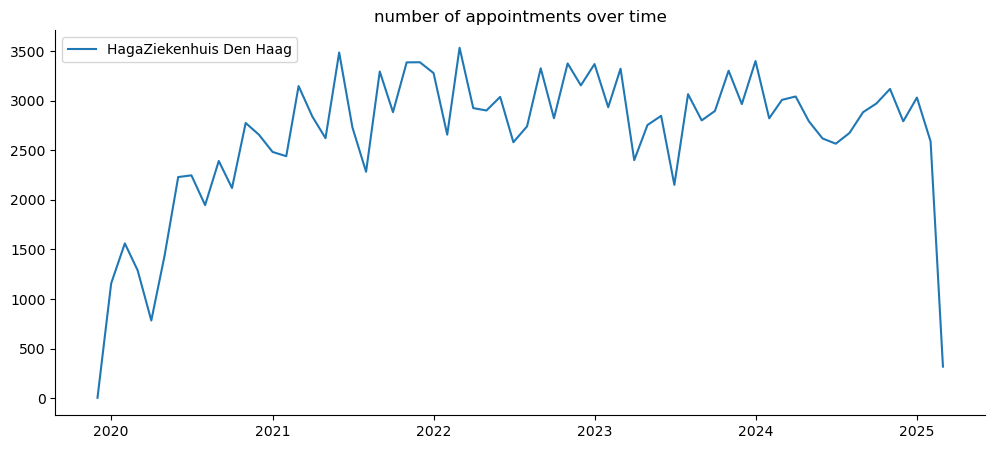

In [4]:
no_show_over_time = appointments_df.copy().reset_index()
no_show_over_time["start"] = (
    no_show_over_time["start"].dt.to_period("M").dt.to_timestamp()
)
no_show_over_time = no_show_over_time.groupby(["ziekenhuis", "start"])["no_show"].count()

fig, ax = plt.subplots(figsize=(12, 5))
for idx in no_show_over_time.index.unique(level="ziekenhuis"):
    ax.plot(
        no_show_over_time.loc[idx].index,
        no_show_over_time.loc[idx],
        label=idx,
    )
ax.legend()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.set_title("number of appointments over time")

plt.show()

In [5]:
appointments_features = prev_no_show_features(appointments_df)
appointments_features = add_days_since_created(appointments_features)
appointments_features = add_appointments_same_day(appointments_features)

KeyError: 'prev_minutes_early'

In [ ]:
feature_scatter(appointments_features, "days_since_created")
plt.show()

In [ ]:
print(appointments_features['no_show'].unique())

In [ ]:
bin_edges = [0,3,7,14,21,31]
bin_labels = ['0-3','4-7','8-14','15-21','21-31']

appointments_features['days_since_bins'] = pd.cut(appointments_features['days_since_created'],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

In [ ]:
feature_scatter(appointments_features, "days_since_bins")
plt.show()

In [ ]:
test = appointments_features['minutesDuration'].value_counts()
print(test)

In [ ]:
appointments_features = add_appointments_same_day(appointments_features)
test = appointments_features['appointments_same_day'].value_counts()
print(test)

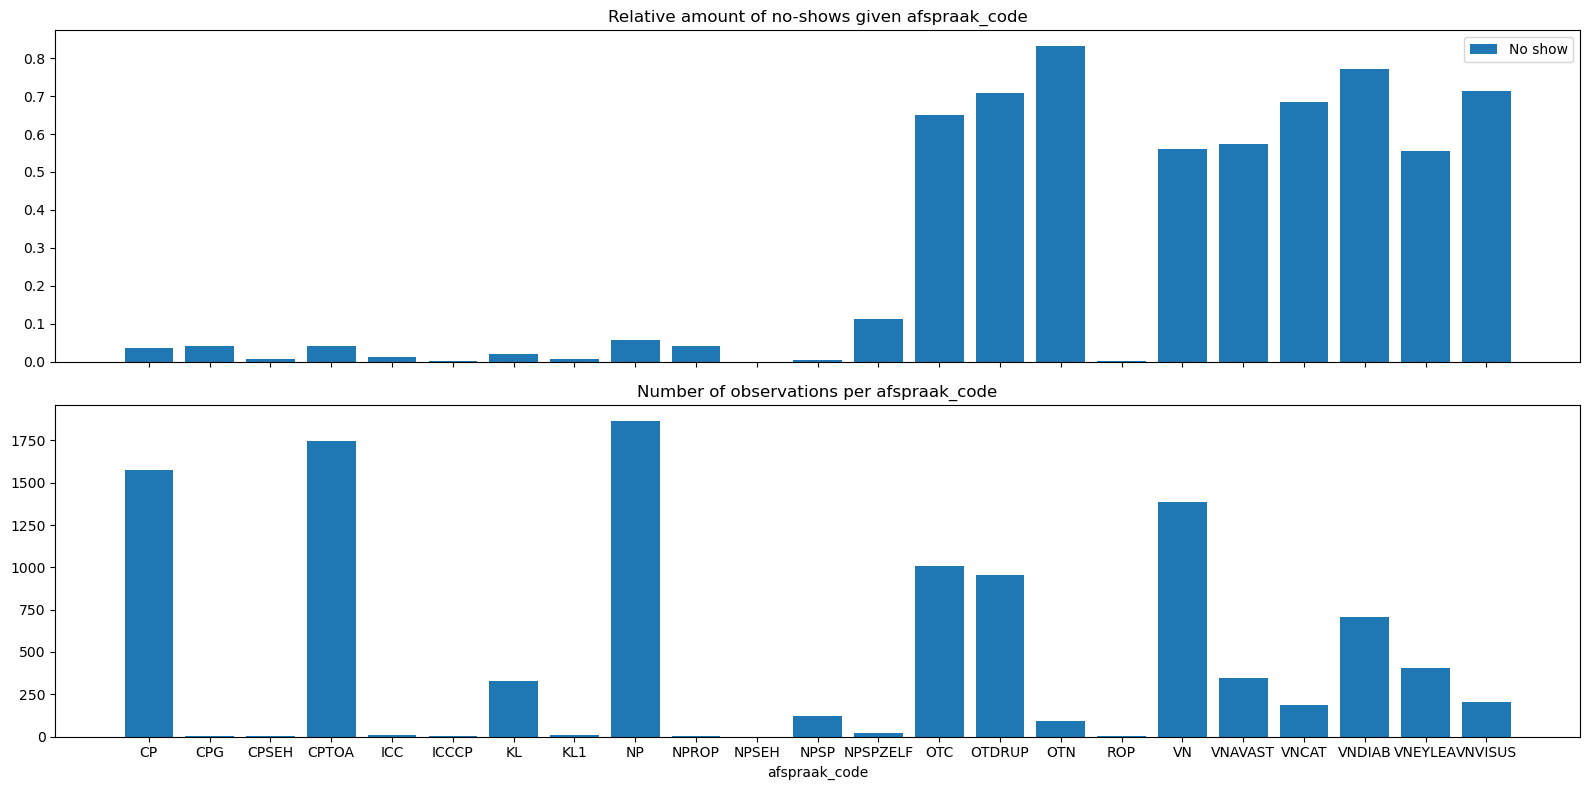

In [7]:
test = appointments_features[appointments_features.groupby("afspraak_code")['afspraak_code'].transform('count') > 50]

ax = feature_barplot(
    test,
    "afspraak_code",
    feature_name="afspraak_code",
)
plt.tight_layout()
plt.show()

In [8]:
appointments_features["no_show"] = (
        appointments_features["no_show"].replace({"no_show": "1", "show": "0"}).astype(int)
    )


In [9]:

subset = appointments_features[appointments_features['minutesDuration'] == 10]

count = subset['no_show'].sum()
total_app = len(subset)

no_show_perc = (count / total_app) * 100 if total_app > 0 else 0

print(total_app)
print(no_show_perc)


150847
4.720014319144564


In [10]:
appoints_dur = appointments_features[appointments_features['minutesDuration'] == 20]
#appoints_dur = appoints_dur[appoints_dur['appointments_same_day'] > 1]

count = appoints_dur['no_show'].sum()
total_app = len(appoints_dur)

no_show_perc = (count / total_app) * 100 if total_app > 0 else 0

print(total_app)
print(no_show_perc)

4594
66.15150195907705


In [11]:
appoints_dur = appointments_features[appointments_features['appointments_same_day'] > 1]

count = appoints_dur['no_show'].sum()
total_app = len(appoints_dur)

no_show_perc = (count / total_app) * 100 if total_app > 0 else 0

print(total_app)
print(no_show_perc)

4813
51.52711406607106


In [12]:
appoints_dur = appointments_features[appointments_features['appointments_same_day'] == 2]
total_app = len(appoints_dur)
print(total_app)

4682


In [13]:
appoints_dur = appointments_features[appointments_features['appointments_same_day'] == 2]
appoints_dur['date'] = pd.to_datetime(appoints_dur.index.get_level_values('start'), unit='s').date
appoints_dur = appoints_dur.sort_values(['pseudo_id', 'date', 'start'])

appoints_dur['position'] = appoints_dur.groupby(['pseudo_id', 'date']).cumcount()

#print(appoints_dur[['date', 'position']].head(10))

pivoted = appoints_dur.pivot_table(index=['pseudo_id', 'date'],
                                   columns='position',
                                   values='no_show',
                                   aggfunc='first')

pivoted.columns = ['first_no_show', 'second']

print(pivoted)

results = pivoted.value_counts().reset_index(name='count')

results['percent'] = results['count'] / results['count'].sum() * 100

print(results)

                                                               first_no_show  \
pseudo_id                                          date                        
000D509BF4E1123636BE64127BEB2B7846C97521A85C64F... 2024-11-21              0   
0033245D30736E5C3B6A8C6A1E34342012A75A42EBA487C... 2023-02-28              0   
0043F9BB09D5CCFEB624F38AC53DF609AC937E0B4EB4B79... 2024-07-10              1   
005CF728E2FD8511A5ED08AB04AFA47A4498D9A821C4C46... 2022-01-10              0   
0076F0307E436AC2DFD52ECCC597054568315CFF45CB145... 2020-01-01              0   
...                                                                      ...   
FFC025F21F4CCCDDECF3B9803C691A208A865B3739BA0BB... 2021-06-02              1   
FFE1932417EE2237E26D2B079E09F2DC9D539E481A8D269... 2024-04-05              0   
FFE33393E7173807F344298A6302466554D08857B0ADFF5... 2023-05-30              0   
                                                   2023-08-21              1   
FFF14899B9A21CED07C8978FC317CADD9C414FAB

/tmp/ipykernel_2805/2717988968.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  appoints_dur['date'] = pd.to_datetime(appoints_dur.index.get_level_values('start'), unit='s').date


In [14]:
feature_scatter(appointments_features, "prev_minutes_early")
plt.show()

KeyError: 'prev_minutes_early'